In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/zece05/DSB-Unit-02/refs/heads/main/Labs/lab-eda-titanic/titanic-train.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


***

**1. Create a bar chart showing how many missing values are in each column**

<Axes: >

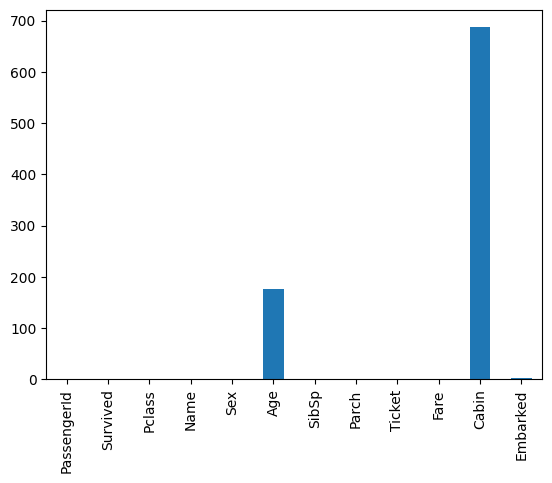

In [3]:
df.isnull().sum().plot(kind='bar')

In [4]:
#!pip install missingno

In [5]:
# import missingno as msno
# %matplotlib inline

# msno.bar(df)

**2. Which column has the most NaN values? How many cells in that column are empty?**

In [6]:
nanval = df.isna().sum().sort_values(ascending=False)
print("column %s has the highest number of nan cells: %i" %(nanval.index[0], nanval.iloc[0]))

column Cabin has the highest number of nan cells: 687


**3. Delete all rows where Embarked is empty**

In [7]:
indeksi = df[df['Embarked'].isna()].index

# df2 is the df where Embarked = nan rows is deleted
df2 = df.drop(indeksi,axis=0)

df2['Embarked'].isna().sum()

np.int64(0)

**4. Fill all empty cabins with**  ¯\(ツ)/¯

In [8]:
df2['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'C83', 'F33', 'F G73',
       'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101', 'F E69',
       'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4', 'A32',
       'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35', 'C87',
       'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19', 'B49',
       'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54', 'B57 B59 B63 B66',
       'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40', 'T', 'C128',
       'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44', 'A34', 'C104',
       'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14', 'B37', 'C30',
       'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38', 'B39', 'B22',
       'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68', 'B41', 'A20',
       'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48', 'E58', 'C126',
       'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63', 'C62 C64',
       'E24',

In [9]:
print("Nan Cabin cells before: %s" %df2['Cabin'].isna().sum())

marsovac = r"¯\(ツ)/¯"
# df3 is with fillna df2['Cabin'] values
df3 = df2.copy()
df3['Cabin'] = df2['Cabin'].fillna(marsovac)

print('Now, there are %i cells with %s' %(df3['Cabin'][df3['Cabin']==marsovac].count(), marsovac))

Nan Cabin cells before: 687
Now, there are 687 cells with ¯\(ツ)/¯


## Step 3: Feature extraction


**1. There are two columns that pertain to how many family members are on the boat for a given person. Create a new column called FamilyCount which will be the sum of those two columns.**

In [10]:
#SibSp  -   No. of siblings / spouses aboard the Titanic
#Parch  -   No. of parents / children aboard the Titanic

df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    int64  
 2   Pclass       889 non-null    int64  
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          712 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Cabin        889 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 90.3+ KB


In [11]:
# Because, Parch and SibSp are int64, we can just add them up...
df3['FamilyCount'] = df3['Parch'] + df3['SibSp']
df3.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,¯\(ツ)/¯,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,¯\(ツ)/¯,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,¯\(ツ)/¯,S,0


**2. Reverends have a special title in their name. Create a column called IsReverend: 1 if they're a preacher, 0 if they're not.**

In [12]:
df3['IsReverend'] = df3['Name'].str.lower().str.contains("rev.", na=False, regex=False).astype(int)

In [13]:
df3.iloc[145:155]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilyCount,IsReverend
146,147,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,¯\(ツ)/¯,S,0,0
147,148,0,3,"Ford, Miss. Robina Maggie ""Ruby""",female,9.0,2,2,W./C. 6608,34.3750,¯\(ツ)/¯,S,4,0
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.5,0,2,230080,26.0000,F2,S,2,0
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.0000,¯\(ツ)/¯,S,0,1
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.5250,¯\(ツ)/¯,S,0,1
151,152,1,1,"Pears, Mrs. Thomas (Edith Wearne)",female,22.0,1,0,113776,66.6000,C2,S,1,0
152,153,0,3,"Meo, Mr. Alfonzo",male,55.5,0,0,A.5. 11206,8.0500,¯\(ツ)/¯,S,0,0
153,154,0,3,"van Billiard, Mr. Austin Blyler",male,40.5,0,2,A/5. 851,14.5000,¯\(ツ)/¯,S,2,0
154,155,0,3,"Olsen, Mr. Ole Martin",male,NaN,0,0,Fa 265302,7.3125,¯\(ツ)/¯,S,0,0
155,156,0,1,"Williams, Mr. Charles Duane",male,51.0,0,1,PC 17597,61.3792,¯\(ツ)/¯,C,1,0


**3. In order to feed our training data into a classification algorithm, we need to convert our categories into 1's and 0's using pd.get_dummies**

In [14]:
print("before ...\n****************")
print(df3.columns)
print(df3.shape)

df4 = pd.get_dummies(df3, columns = ['Embarked'], dtype='int')
df4 = pd.get_dummies(df4, columns = ['Sex'], dtype='int')

print("after pd.get_dummies(df3) ...\n****************")
print(df4.columns)
print(df4.shape)

before ...
****************
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'FamilyCount',
       'IsReverend'],
      dtype='object')
(889, 14)
after pd.get_dummies(df3) ...
****************
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilyCount', 'IsReverend', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Sex_female', 'Sex_male'],
      dtype='object')
(889, 17)


In [15]:
# BONUS

df4['TitleInName'] = df4['Name'].apply(lambda x: x.split(',')[1].split('.')[0])
df4 = pd.get_dummies(df4, columns= ["TitleInName"], dtype='int')

print("after BONUS ...\n****************")
print(df4.columns)
print(df4.shape)

after BONUS ...
****************
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'FamilyCount', 'IsReverend', 'Embarked_C',
       'Embarked_Q', 'Embarked_S', 'Sex_female', 'Sex_male',
       'TitleInName_ Capt', 'TitleInName_ Col', 'TitleInName_ Don',
       'TitleInName_ Dr', 'TitleInName_ Jonkheer', 'TitleInName_ Lady',
       'TitleInName_ Major', 'TitleInName_ Master', 'TitleInName_ Miss',
       'TitleInName_ Mlle', 'TitleInName_ Mme', 'TitleInName_ Mr',
       'TitleInName_ Mrs', 'TitleInName_ Ms', 'TitleInName_ Rev',
       'TitleInName_ Sir', 'TitleInName_ the Countess'],
      dtype='object')
(889, 34)


## Step 4: Exploratory analysis

**1. What was the survival rate overall?**

In [16]:
df4['Survived'].unique()

array([0, 1])

In [17]:
sr = df4['Survived'].mean().round(4) * 100

print('Overall survival rate is: %.2f %%' %sr)

Overall survival rate is: 38.25 %


**2. Which gender fared the worst? What was their survival rate?**

In [18]:
sps = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False)*100
sps

,Survived
Sex,
female,74.203822
male,18.890815


In [19]:
print("Based on the result that survival rate for %s was %.1f %% and for %s was %.1f %%\nWe can conclude that %s passangers fared worse" %(sps.index[0], sps.iloc[0], sps.index[1], sps.iloc[1], sps.index[0]))

Based on the result that survival rate for female was 74.2 % and for male was 18.9 %
We can conclude that female passangers fared worse


3. What was the survival rate for each Pclass?


In [20]:
pps = df.groupby('Pclass')['Survived'].mean().round(3).sort_values(ascending=False)*100
pps = pps.rename("Survival %")
pps

,Survival %
Pclass,
1,63.0
2,47.3
3,24.2


**4. Did any reverends survive? How many?**


In [21]:
ps = df[df['Name'].str.contains('Rev.')]['Survived'].mean()
print('As survival rate for revenders was %.1f %%\nThere were no survived revenders' %ps)

As survival rate for revenders was 0.0 %
There were no survived revenders


In [22]:
df4.groupby("IsReverend")["Survived"].agg(["count", "sum", "mean"])

,count,sum,mean
IsReverend,,,
0,883,340,0.385051
1,6,0,0.000000


**5. What is the survival rate for cabins marked ¯\(ツ)/¯**


In [23]:
cs = df4[df4['Cabin']==marsovac]['Survived'].mean()*100
print('Survival rate for %s Cabin was %.1f %%' %(marsovac, cs))

Survival rate for ¯\(ツ)/¯ Cabin was 30.0 %


**6. What is the survival rate for people whose Age is empty?**

In [24]:
ans = df[df['Age'].isnull()]['Survived'].mean()*100
print('Survival rate for passangers with nan age was %.1f %%' %(ans))

Survival rate for passangers with nan age was 29.4 %


**7. What is the survival rate for each port of embarkation?**

In [25]:
eps = df.groupby('Embarked')['Survived'].mean().round(3)*100
eps = eps.rename('Survival %')
eps

,Survival %
Embarked,
C,55.4
Q,39.0
S,33.7


**8. What is the survival rate for children (under 12) in each Pclass?**

In [26]:
df[df['Age']<12].groupby('Pclass').count()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
Pclass,,,,,,,,,,,
1,4,4,4,4,4,4,4,4,4,4,4
2,17,17,17,17,17,17,17,17,17,4,17
3,47,47,47,47,47,47,47,47,47,3,47


In [27]:
df[df['Age']<12].groupby('Pclass')['Survived'].mean().round(3)*100

,Survived
Pclass,
1,75.0
2,100.0
3,40.4


**9.Did the captain of the ship survive? Is he on the list?**

In [28]:
df4['TitleInName_ Capt'].sum()

np.int64(1)

In [29]:
cs = df4[df4['TitleInName_ Capt']==1]['Survived'].values

if cs==1:
  print('Captain survived')
elif cs==0:
  print("Captain didn't survive")
else:
  print("No information about captain survival")

Captain didn't survive


**10. Of all the people that died, who had the most expensive ticket? How much did it cost?**

In [30]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [31]:
# There is the same ticket for more than one person, so we have to count how many people share the ame ticket to find price per person, not price of ticket
df['Ticket'].value_counts(ascending=False)

,count
Ticket,
347082,7
1601,7
CA. 2343,7
3101295,6
CA 2144,6
...,...
PC 17590,1
17463,1
330877,1


In [32]:
df['FarePricePerPerson'] = (df['Fare'] / df.groupby('Ticket')['Ticket'].transform("count")).round(2)
df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FarePricePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,7.25
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,71.28
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q,8.46
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,51.86
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S,5.27
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S,3.71
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C,15.04


In [33]:
df.loc[df['Survived']==0, 'FarePricePerPerson'].nlargest(1)

,FarePricePerPerson
527,221.78


In [34]:
df.iloc[527]

,527
PassengerId,528
Survived,0
Pclass,1
Name,"Farthing, Mr. John"
Sex,male
Age,NaN
SibSp,0
Parch,0
Ticket,PC 17483
Fare,221.7792


In [35]:
print('Among those who didn"t survive, %s paid the most %.2f £ per person.' %(df.iloc[527].Name, df.iloc[527].FarePricePerPerson))

Among those who didn"t survive, Farthing, Mr. John paid the most 221.78 £ per person.


**11. Does having family on the boat help or hurt your chances of survival?**

In [36]:
df3.groupby([df3['FamilyCount']>0])['Survived'].mean()

,Survived
FamilyCount,
False,0.300935
True,0.505650


In [37]:
print("About 50% of passengers travelling with family survived, compared with only 30% of those travelling alone, so we can conclude that having family on board improved the chances of survival.")

About 50% of passengers travelling with family survived, compared with only 30% of those travelling alone, so we can conclude that having family on board improved the chances of survival.


## Step 5: Plotting

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

BG, AXIS, TEXT = "#E6E8EB", "#4A505C", "#0D1117"
PINK, CYAN, AMBER, VIOLET, TEAL = "#E63946", "#3A86FF", "#FB8500", "#8D99AE", "#2A9D8F"
#PINK, CYAN, AMBER, VIOLET, TEAL = "#F72585", "#4CC9F0", "#FFB703", "#7B2CBF", "#2EC4B6"
#RED, BLUE, ORANGE, STEEL, GREEN = "#E63946", "#3A86FF", "#FB8500", "#8D99AE", "#2A9D8F"


sns.set_theme(style="darkgrid", palette=[PINK, CYAN, AMBER, VIOLET, TEAL], rc={
    "figure.figsize": (9, 5),
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.edgecolor": AXIS, "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": TEXT, "axes.labelcolor": TEXT,
    "xtick.color": TEXT, "ytick.color": TEXT,
    "axes.titleweight": "bold", "axes.titlesize": 16, "axes.labelweight": "bold",
    "legend.frameon": False, "patch.edgecolor": BG,
})

def finish(ax, title, xlabel):
    for bars in ax.containers:
        ax.bar_label(bars, fmt="{:.0%}", color=TEXT, fontweight="bold", padding=3)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim(0, 1.1)
    ax.set(xlabel=xlabel, ylabel="Survival Rate")
    ax.set_title(title, loc="left", pad=15)
    plt.show()

In [39]:
df_plot = df.copy()
df_plot["Class"] = df_plot["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"})
df_plot["Port"] = df_plot["Embarked"].map({"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"})
df_plot["FamilySize"] = (df_plot["SibSp"] + df_plot["Parch"] + 1).clip(upper=5)
df_plot["TravelGroup"] = np.where(df_plot["FamilySize"] == 1, "Alone", "With family")
df_plot["AgeGroup"] = pd.cut(df_plot["Age"], bins=[0, 12, 17, 29, 49, 100],
                       labels=["0-12", "13-17", "18-29", "30-49", "50+"])
df_plot["Who"] = np.where(df_plot["Age"] < 16, "Child", np.where(df_plot["Sex"] == "female", "Woman", "Man"))
CLASSES = ["1st", "2nd", "3rd"]

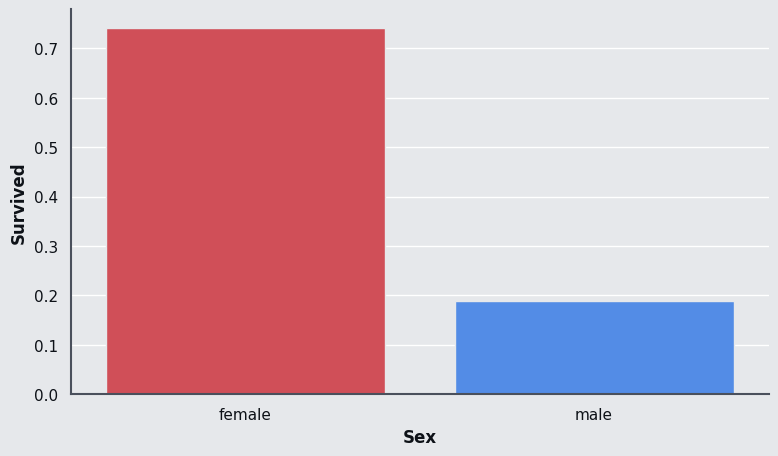

In [40]:
ax = sns.barplot(data=df_plot, x="Sex", y="Survived", hue="Sex", order=["female", "male"],
                 palette={"female": PINK, "male": CYAN}, errorbar=None)

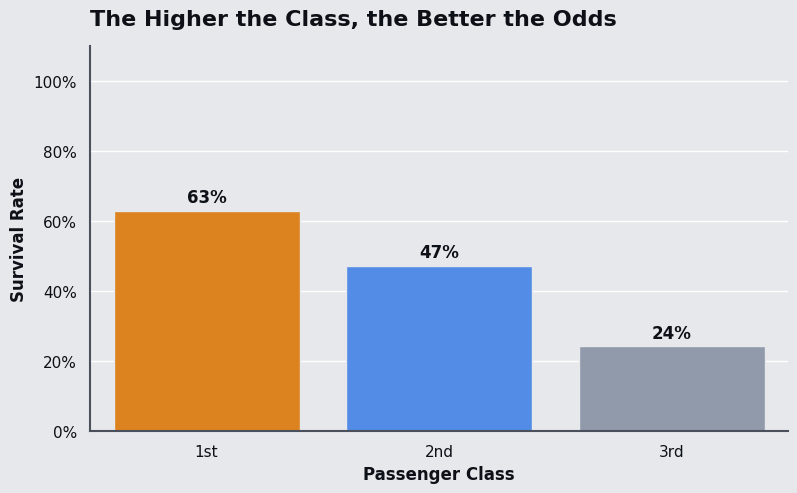

In [41]:
ax = sns.barplot(data=df_plot, x="Class", y="Survived", hue="Class", order=CLASSES,
                 palette={"1st": AMBER, "2nd": CYAN, "3rd": VIOLET}, errorbar=None)
finish(ax, "The Higher the Class, the Better the Odds", "Passenger Class")

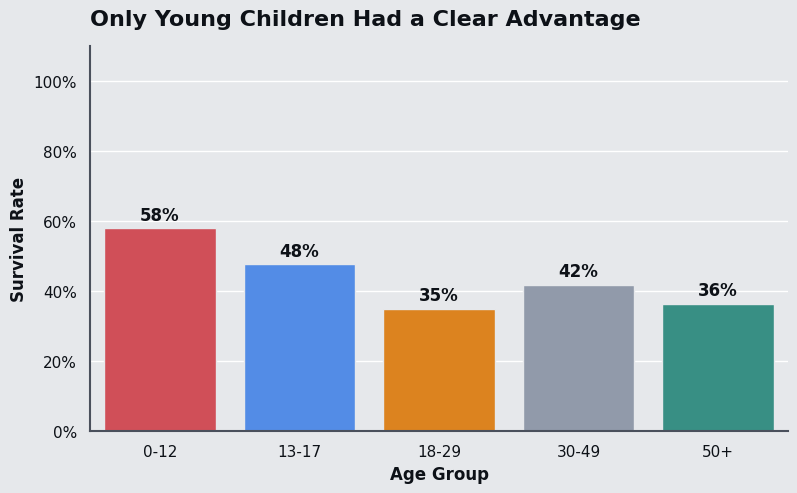

In [42]:
ax = sns.barplot(data=df_plot, x="AgeGroup", y="Survived", hue="AgeGroup", dodge=False, errorbar=None, legend=False)
finish(ax, "Only Young Children Had a Clear Advantage", "Age Group")

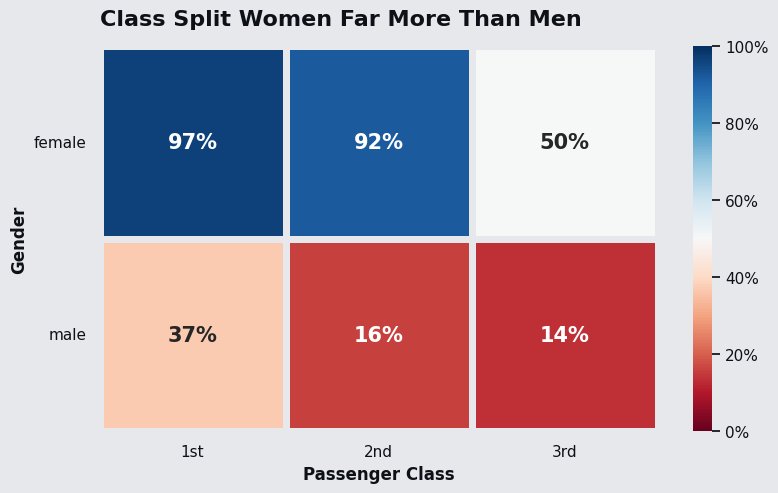

In [43]:
pivot = df_plot.pivot_table(index="Sex", columns="Class", values="Survived")
ax = sns.heatmap(pivot, annot=True, fmt=".0%", cmap="RdBu", vmin=0, vmax=1,
                 linewidths=5, linecolor=BG, annot_kws={"fontsize": 15, "fontweight": "bold"},
                 cbar_kws={"format": PercentFormatter(1)})
ax.set(xlabel="Passenger Class", ylabel="Gender")
plt.yticks(rotation=0)
ax.set_title("Class Split Women Far More Than Men", loc="left", pad=15)
plt.show()

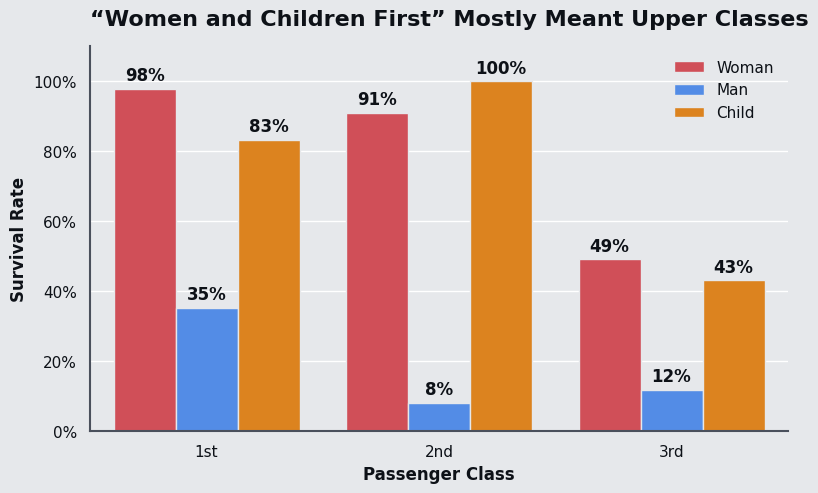

In [44]:
ax = sns.barplot(data=df_plot, x="Class", y="Survived", hue="Who", order=CLASSES,
                 hue_order=["Woman", "Man", "Child"], errorbar=None)
ax.legend(title="")
finish(ax, "“Women and Children First” Mostly Meant Upper Classes", "Passenger Class")

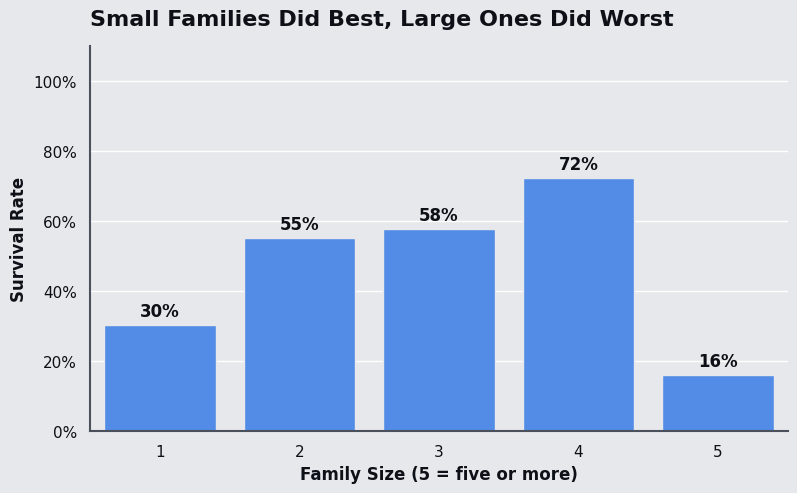

In [45]:
ax = sns.barplot(data=df_plot, x="FamilySize", y="Survived", color=CYAN, errorbar=None)
finish(ax, "Small Families Did Best, Large Ones Did Worst", "Family Size (5 = five or more)")

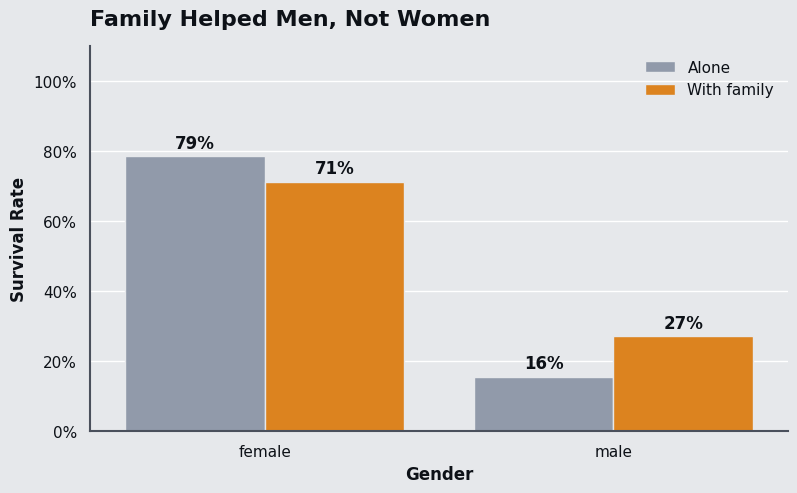

In [46]:
ax = sns.barplot(data=df_plot, x="Sex", y="Survived", hue="TravelGroup", order=["female", "male"],
                 hue_order=["Alone", "With family"],
                 palette={"Alone": VIOLET, "With family": AMBER}, errorbar=None)
ax.legend(title="")
finish(ax, "Family Helped Men, Not Women", "Gender")

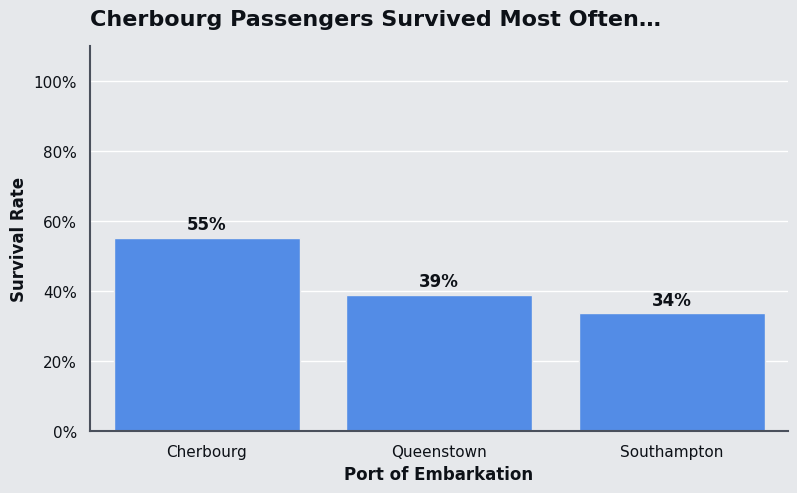

In [47]:
ax = sns.barplot(data=df_plot, x="Port", y="Survived", color=CYAN, errorbar=None,
                 order=["Cherbourg", "Queenstown", "Southampton"])
finish(ax, "Cherbourg Passengers Survived Most Often…", "Port of Embarkation")

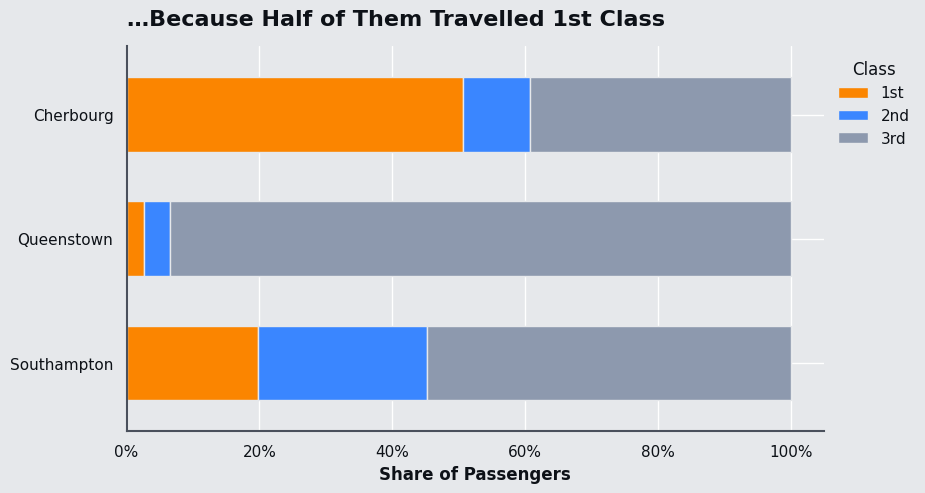

In [48]:
mix = pd.crosstab(df_plot["Port"], df_plot["Class"], normalize="index")
ax = mix.plot(kind="barh", stacked=True, color=[AMBER, CYAN, VIOLET], width=0.6)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.invert_yaxis()
ax.set(xlabel="Share of Passengers", ylabel="")
ax.legend(title="Class", bbox_to_anchor=(1, 1))
ax.set_title("…Because Half of Them Travelled 1st Class", loc="left", pad=15)
plt.show()

In [49]:
### TO JE TO...